In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/listings.csv.gz")
df.shape

(13225, 90)

In [2]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1534226092176355661,https://www.airbnb.com/rooms/1534226092176355661,20260627230126,2026-06-29,city scrape,Private Suite Oceanfront La Jolla,Private suite in Ocean front Estate in La Jolla,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,14064859,...,NaN,NaN,NaN,NaN,NaN,9,6,3,0,NaN
1,1151093362948878244,https://www.airbnb.com/rooms/1151093362948878244,20260627230126,2026-06-29,city scrape,Magical view,Luxury high rise building fully remodeled with...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,365015269,...,NaN,NaN,NaN,STR-08000L,NaN,1,1,0,0,NaN
2,46566873,https://www.airbnb.com/rooms/46566873,20260627230126,2026-06-28,city scrape,Highland on 60th Large 3BR 4 Beds/2 BA Near SDSU,Centrally located single-family home with a la...,NaN,https://a0.muscache.com/pictures/5b341abe-0010...,21897271,...,4.98,4.91,4.91,"STR-01411L, 644117",NaN,1,1,0,0,3.40
3,683340460312082362,https://www.airbnb.com/rooms/683340460312082362,20260627230126,2026-07-02,previous scrape,"Beautiful, Private Bed & Bath in Central Location",Keep it simple at this peaceful and centrally-...,NaN,https://a0.muscache.com/pictures/airflow/Hosti...,21788590,...,5.00,4.95,5.00,"STR-06725L, 644561",NaN,2,1,1,0,0.45
4,50119879,https://www.airbnb.com/rooms/50119879,20260627230126,2026-06-29,city scrape,Wooden Craftsman Home w/ Private Backyard & Ga...,Make this entire space your new home away from...,NaN,https://a0.muscache.com/pictures/8b957cbc-f489...,117810403,...,4.93,4.98,4.79,"STR-06662L, 648042",NaN,1,1,0,0,0.95


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13225 entries, 0 to 13224
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            13225 non-null  int64  
 1   listing_url                                   13225 non-null  object 
 2   scrape_id                                     13225 non-null  int64  
 3   last_scraped                                  13225 non-null  object 
 4   source                                        13225 non-null  object 
 5   name                                          13225 non-null  object 
 6   description                                   13088 non-null  object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   13225 non-null  object 
 9   host_id                                       13225 non-null 

In [4]:
cols = [
    "price", "room_type", "neighbourhood_cleansed", "accommodates",
    "bedrooms", "bathrooms_text", "minimum_nights", "number_of_reviews",
    "review_scores_rating", "host_response_rate", "host_is_superhost",
    "availability_365",
]
df = df[cols].copy()
df.isna().sum()

price                      1369
room_type                     0
neighbourhood_cleansed        0
accommodates                  0
bedrooms                   2034
bathrooms_text               63
minimum_nights               12
number_of_reviews             0
review_scores_rating       2232
host_response_rate        13225
host_is_superhost            32
availability_365              0
dtype: int64

In [5]:
cols = [
    "price", "room_type", "neighbourhood_cleansed", "accommodates",
    "bedrooms", "bathrooms_text", "minimum_nights", "number_of_reviews",
    "review_scores_rating", "host_response_rate", "host_is_superhost",
    "availability_365",
]
df = df[cols].copy()
df.isna().sum()

price                      1369
room_type                     0
neighbourhood_cleansed        0
accommodates                  0
bedrooms                   2034
bathrooms_text               63
minimum_nights               12
number_of_reviews             0
review_scores_rating       2232
host_response_rate        13225
host_is_superhost            32
availability_365              0
dtype: int64

In [6]:
df["price"] = (
    df["price"]
    .replace(r"[\$,]", "", regex=True)
    .astype(float)
)
df["price"].describe()

count    11856.000000
mean       483.802383
std        987.207536
min          5.500000
25%        175.457500
50%        322.920000
75%        589.000000
max      82340.820000
Name: price, dtype: float64

In [7]:
df = df[df["price"].between(10, 1000)]
df["price"].describe()

count    10744.000000
mean       352.172851
std        232.682258
min         12.320000
25%        163.260000
50%        290.395000
75%        494.715000
max       1000.000000
Name: price, dtype: float64

/Users/andrewhashoush/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


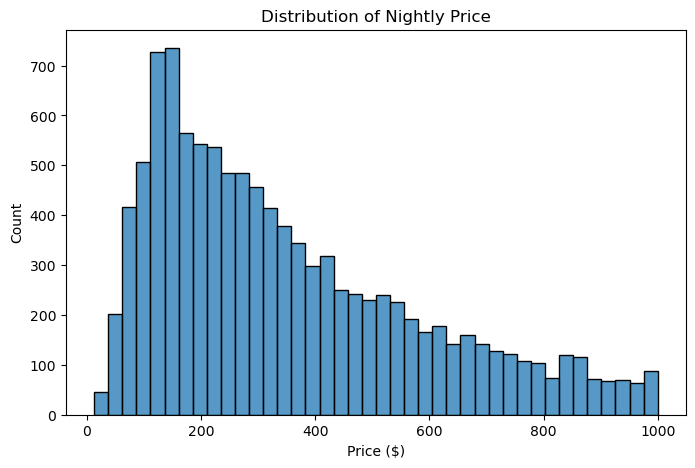

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=40)
plt.title("Distribution of Nightly Price")
plt.xlabel("Price ($)")
plt.show()

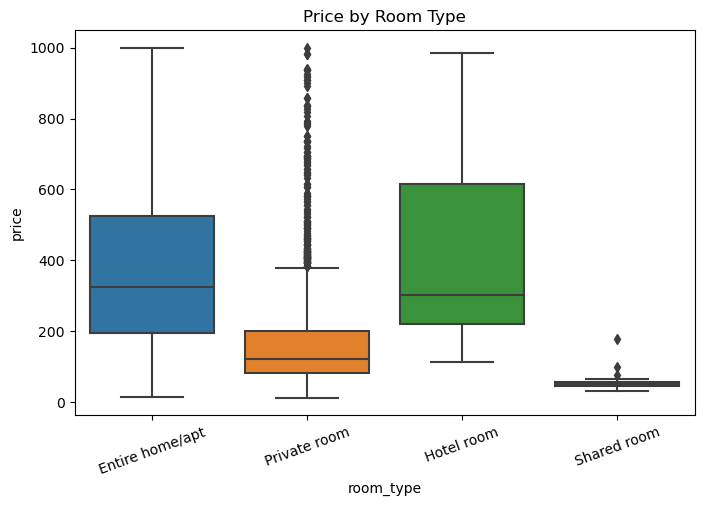

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="room_type", y="price")
plt.title("Price by Room Type")
plt.xticks(rotation=20)
plt.show()

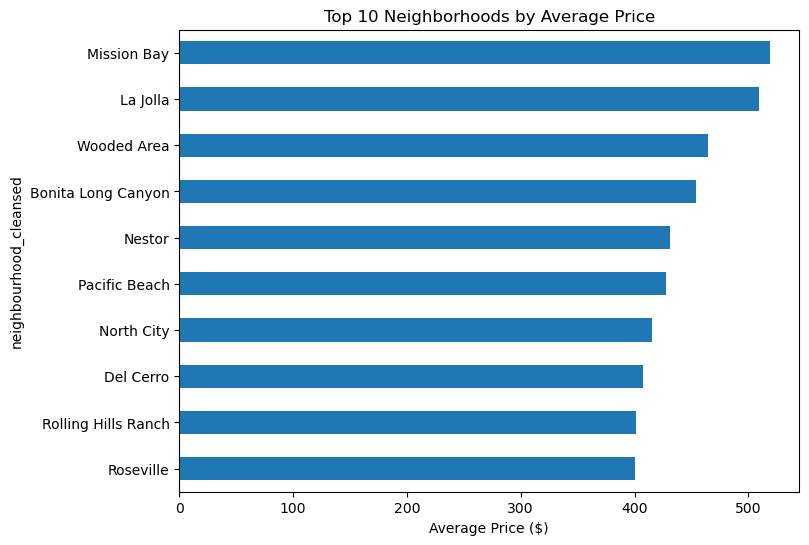

In [10]:
top_neighborhoods = (
    df.groupby("neighbourhood_cleansed")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
top_neighborhoods.plot(kind="barh", figsize=(8, 6))
plt.title("Top 10 Neighborhoods by Average Price")
plt.xlabel("Average Price ($)")
plt.gca().invert_yaxis()
plt.show()

In [11]:
df.groupby("host_is_superhost")["price"].mean()

host_is_superhost
f    313.966151
t    382.343678
Name: price, dtype: float64

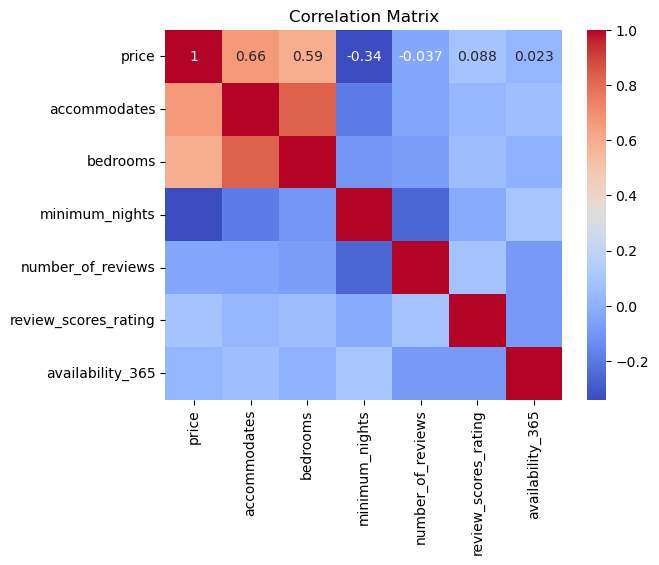

In [12]:
numeric_cols = ["price", "accommodates", "bedrooms", "minimum_nights",
                 "number_of_reviews", "review_scores_rating", "availability_365"]
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()